# Notebook 06 — Train Mamba (SSM)

Selective State-Space Model for multi-site AirNow NO₂ forecasting (Gu & Dao, 2023).

**Input :** `(batch, seq_len, n_sites)` — normalised look-back window  
**Output :** `(batch, pred_len, n_sites)` — forecast horizon  
**Architecture :** `Linear → MambaBlock × n_layers [conv1d + selective SSM + gate] → Flatten → Linear`


In [1]:
import json, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

from data.load_airnow import load_sequences, DATA_DIR, TRAIN_END, FULL_TRAIN_END
from models.mamba_no2 import NO2Mamba
from models.transformer_no2 import _make_loader, evaluate

OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEQ_LEN    = 24      # look-back window (hours)
PRED_LEN   = 6       # forecast horizon (hours)
D_MODEL    = 128     # state dimension
N_LAYERS   = 3       # Mamba blocks
D_STATE    = 16      # SSM state size
EXPAND     = 2       # inner-dim expansion factor
DROPOUT    = 0.1
EPOCHS     = 50
BATCH_SIZE = 64
LR         = 1e-3
PATIENCE   = 8

# ── Split boundaries (12-month train / 3-month test) ──────────────────────────
# Train   : 2023-07-01 → 2024-05-31  (TRAIN_END)
# Val     : 2024-06-01 → 2024-06-30  (FULL_TRAIN_END)   ─╮  12-month
# Test    : 2024-07-01 → 2024-09-30               ─╯  held-out

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device     : {DEVICE}")
print(f"Config     : seq={SEQ_LEN}h  pred={PRED_LEN}h  d={D_MODEL}  layers={N_LAYERS}  d_state={D_STATE}")
print(f"Train end  : {TRAIN_END.date()}   Val end : {FULL_TRAIN_END.date()}")


Device     : cpu
Config     : seq=24h  pred=6h  d=128  layers=3  d_state=16
Train end  : 2024-05-31   Val end : 2024-06-30


/mnt/data3/isybelle1118/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1 · Load & Split Data


In [2]:
print("Loading sequences …")
X, y, timestamps, site_codes = load_sequences(
    DATA_DIR, seq_len=SEQ_LEN, pred_len=PRED_LEN,
    stride=1, fill_nan=0.0, normalize=True,
    norm_end=str(TRAIN_END),            # normalise on training data only
)
N_SITES = X.shape[2]

ts        = pd.to_datetime(timestamps)
idx_train = ts <= TRAIN_END
idx_val   = (ts > TRAIN_END) & (ts <= FULL_TRAIN_END)
idx_test  = ts > FULL_TRAIN_END

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

print(f"  Sites     : {N_SITES}")
print(f"  Train     : {idx_train.sum():,} windows  ({ts[idx_train][0].date()} → {ts[idx_train][-1].date()})")
print(f"  Val       : {idx_val.sum():,} windows  ({ts[idx_val][0].date()} → {ts[idx_val][-1].date()})")
print(f"  Test      : {idx_test.sum():,} windows  ({ts[idx_test][0].date()} → {ts[idx_test][-1].date()})")


Loading sequences …


  Sites     : 197
  Train     : 8,064 windows  (2023-07-01 → 2024-05-31)
  Val       : 720 windows  (2024-06-01 → 2024-06-30)
  Test      : 2,179 windows  (2024-07-01 → 2024-09-29)


## 2 · Build Model


In [3]:
model = NO2Mamba(
    n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN,
    d_model=D_MODEL, n_layers=N_LAYERS,
    d_state=D_STATE, expand=EXPAND, dropout=DROPOUT,
)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nParameters : {n_params:,}")

CKPT_NAME = f"mamba_s{SEQ_LEN}_p{PRED_LEN}_d{D_MODEL}.pt"
CKPT_PATH = OUTPUTS / CKPT_NAME
print(f"Checkpoint : {CKPT_PATH}")


NO2Mamba(
  (input_proj): Linear(in_features=197, out_features=128, bias=True)
  (blocks): ModuleList(
    (0-2): 3 x MambaBlock(
      (in_proj): Linear(in_features=128, out_features=512, bias=False)
      (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
      (x_proj): Linear(in_features=256, out_features=48, bias=False)
      (dt_proj): Linear(in_features=16, out_features=256, bias=True)
      (out_proj): Linear(in_features=256, out_features=128, bias=False)
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (drop): Dropout(p=0.1, inplace=False)
  (output_proj): Linear(in_features=3072, out_features=1182, bias=True)
)

Parameters : 4,020,126
Checkpoint : /mnt/data3/isybelle1118/NO2 Forecasting/outputs/mamba_s24_p6_d128.pt


## 3 · Train


In [4]:
model = model.to(DEVICE)
opt     = torch.optim.Adam(model.parameters(), lr=LR)
sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
loss_fn = nn.MSELoss()
loader  = _make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)

history  = []
best_val = float("inf")
stale    = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(X_train)

    val_mse, val_mae = evaluate(model, X_val, y_val,
                                batch_size=BATCH_SIZE * 4, device=DEVICE)
    sched.step(val_mse)
    row = {"epoch": epoch, "train_mse": train_loss,
           "val_mse": val_mse, "val_mae": val_mae,
           "lr": opt.param_groups[0]["lr"]}
    history.append(row)

    marker = ""
    if val_mse < best_val:
        best_val = val_mse
        stale = 0
        torch.save(model.state_dict(), CKPT_PATH)
        marker = "  ✓ best"
    else:
        stale += 1

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train={train_loss:.4f}  val_mse={val_mse:.4f}  val_mae={val_mae:.4f}  "
          f"lr={opt.param_groups[0]['lr']:.1e}  ({time.time()-t0:.1f}s){marker}")

    if stale >= PATIENCE:
        print(f"\nEarly stopping — best val_mse={best_val:.4f}")
        break

print(f"\nCheckpoint saved → {CKPT_PATH.name}")


Epoch   1/50 | train=0.8118  val_mse=1.5580  val_mae=0.5497  lr=1.0e-03  (34.9s)  ✓ best


Epoch   2/50 | train=0.5405  val_mse=1.5903  val_mae=0.5366  lr=1.0e-03  (31.0s)


Epoch   3/50 | train=0.4568  val_mse=1.8006  val_mae=0.5349  lr=1.0e-03  (31.8s)


Epoch   4/50 | train=0.4026  val_mse=2.0943  val_mae=0.5456  lr=1.0e-03  (31.5s)


Epoch   5/50 | train=0.3702  val_mse=1.7530  val_mae=0.5226  lr=5.0e-04  (30.1s)


Epoch   6/50 | train=0.3211  val_mse=1.8781  val_mae=0.5320  lr=5.0e-04  (32.9s)


Epoch   7/50 | train=0.3031  val_mse=2.0001  val_mae=0.5472  lr=5.0e-04  (33.0s)


Epoch   8/50 | train=0.2924  val_mse=1.9169  val_mae=0.5553  lr=5.0e-04  (33.5s)


Epoch   9/50 | train=0.2838  val_mse=2.0658  val_mae=0.5567  lr=2.5e-04  (30.4s)

Early stopping — best val_mse=1.5580

Checkpoint saved → mamba_s24_p6_d128.pt


## 4 · Evaluate on Test Set


In [5]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
test_mse, test_mae = evaluate(model, X_test, y_test, device=DEVICE)
print(f"{'='*45}")
print(f"  TEST  MSE = {test_mse:.4f}   MAE = {test_mae:.4f}")
print(f"{'='*45}")

meta = {
    "model": "mamba", "n_sites": N_SITES,
    "seq_len": SEQ_LEN, "pred_len": PRED_LEN,
    "d_model": D_MODEL, "n_layers": N_LAYERS,
    "n_params": n_params,
    "test_mse": test_mse, "test_mae": test_mae,
    "history": history,
}
hist_path = OUTPUTS / CKPT_NAME.replace(".pt", "_history.json")
hist_path.write_text(json.dumps(meta, indent=2))
print(f"History saved → {hist_path.name}")


  TEST  MSE = 2.8143   MAE = 0.8010
History saved → mamba_s24_p6_d128_history.json


## 5 · Plots


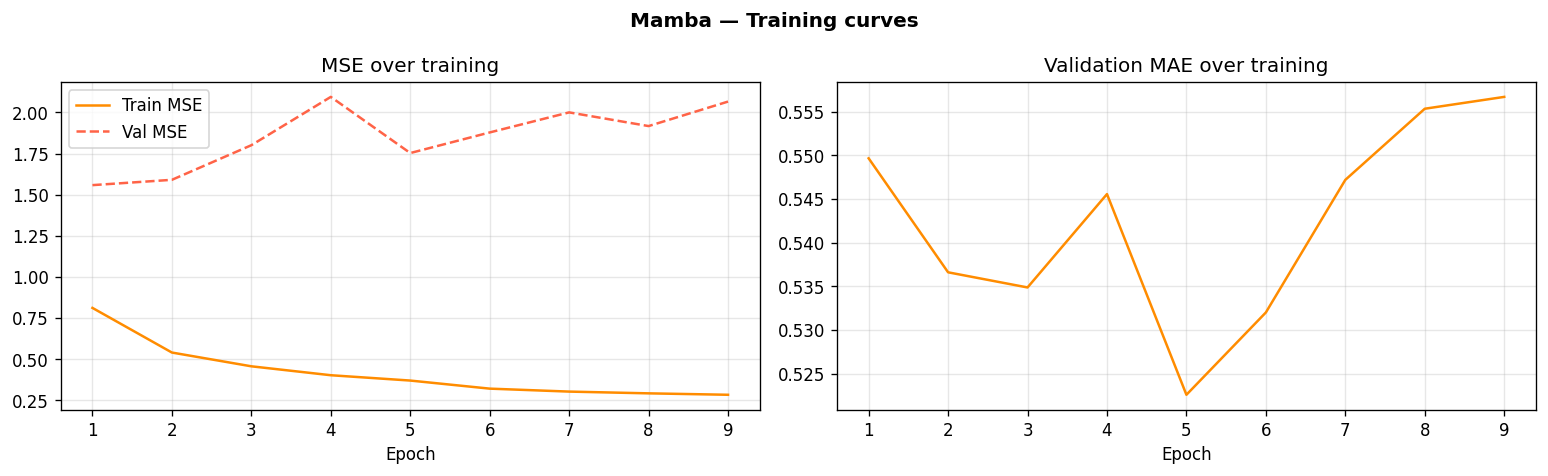

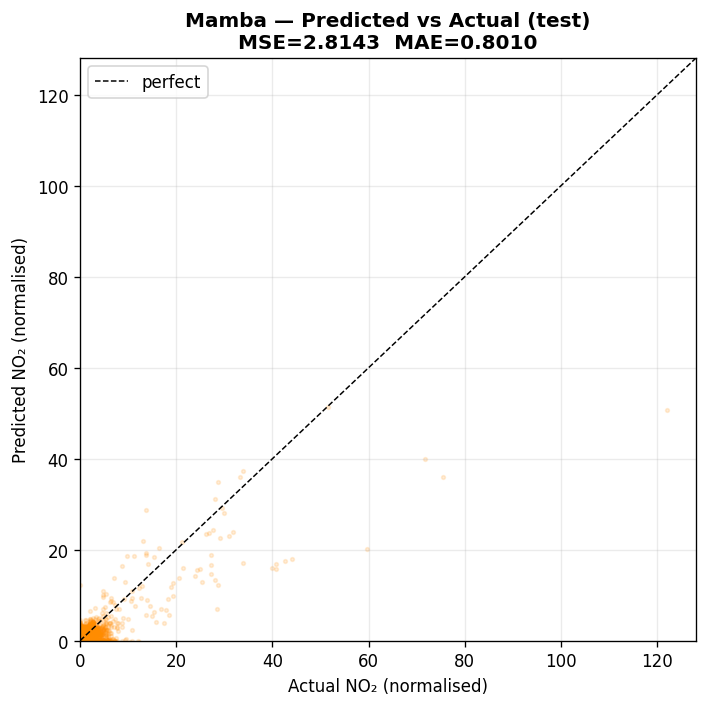

In [6]:
epochs_    = [h["epoch"]     for h in history]
train_mse_ = [h["train_mse"] for h in history]
val_mse_   = [h["val_mse"]   for h in history]
val_mae_   = [h["val_mae"]   for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs_, train_mse_, color="darkorange", label="Train MSE")
axes[0].plot(epochs_, val_mse_,   color="tomato",     label="Val MSE", ls="--")
axes[0].set_title("MSE over training"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_, val_mae_, color="darkorange")
axes[1].set_title("Validation MAE over training"); axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)

fig.suptitle("Mamba — Training curves", fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUTS / "mamba_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Scatter ────────────────────────────────────────────────────────────────────
model.eval()
preds_list = []
with torch.no_grad():
    for xb, _ in _make_loader(X_test, y_test, 512, shuffle=False):
        preds_list.append(model(xb.to(DEVICE)).cpu().numpy())
preds  = np.concatenate(preds_list)
flat_y = y_test.ravel()
flat_p = preds.ravel()
idx    = np.random.choice(len(flat_y), min(8000, len(flat_y)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(flat_y[idx], flat_p[idx], alpha=0.15, s=5, color="darkorange")
lim = max(flat_y[idx].max(), flat_p[idx].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.9, label="perfect")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Actual NO₂ (normalised)")
ax.set_ylabel("Predicted NO₂ (normalised)")
ax.set_title(f"Mamba — Predicted vs Actual (test)\nMSE={test_mse:.4f}  MAE={test_mae:.4f}",
             fontweight="bold")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUTS / "mamba_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
